In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [ ]:
!cp -r /content/gdrive/MyDrive/datasets/merged_dataset /content

In [ ]:
!yolo detect train data=/content/merged_dataset/data.yaml model=yolo11m.pt epochs=60 imgsz=640

Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

In [ ]:
!yolo detect predict model=runs/detect/train2/weights/best.pt source=merged_dataset/images/valid save=True

Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs

image 1/233 /content/merged_dataset/images/valid/blood1_0_w_fake-blood_5_jpg.rf.844e283ada67f91d7409e928491d5c2e.jpg: 640x640 (no detections), 36.8ms
image 2/233 /content/merged_dataset/images/valid/blood1_13_w_bloodstains-window_16_jpg.rf.16cb306acfb3bf3f70b5d80f7f7052ab.jpg: 640x640 (no detections), 36.9ms
image 3/233 /content/merged_dataset/images/valid/blood1_article-2594806-1CC104C400000578-447_306x552_jpg.rf.8022a0f7601252aca9278e2e2e73d868.jpg: 640x640 (no detections), 36.8ms
image 4/233 /content/merged_dataset/images/valid/blood1_blood13_cid_0_fr_10204_ts_00-05-40-133_jpg.rf.ad9bc34173bd9f6409473b5afb5f6bb4.jpg: 640x640 (no detections), 32.8ms
image 5/233 /content/merged_dataset/images/valid/blood1_blood13_cid_0_fr_1149_ts_00-00-38-300_jpg.rf.e9fd50d2931e4f0692e3bab92c533679.jpg: 640x640 (no detections), 25.1ms


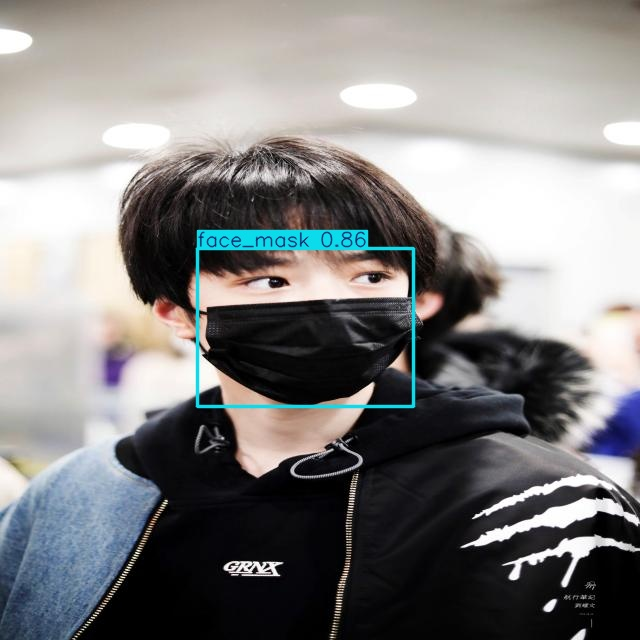

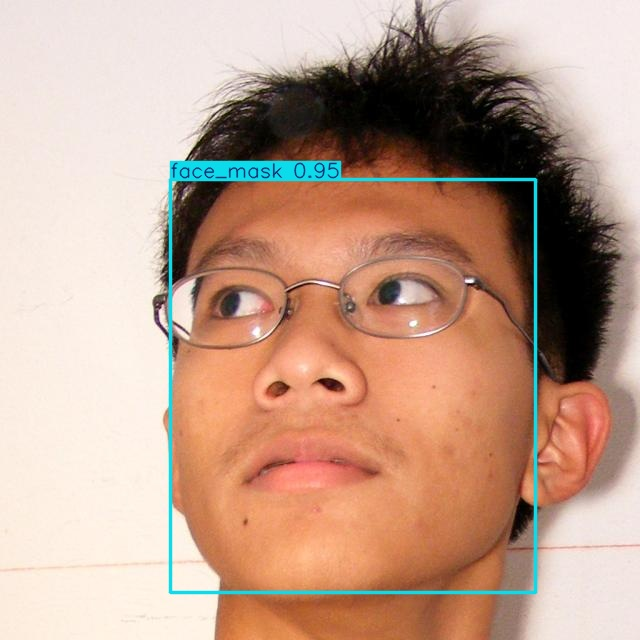

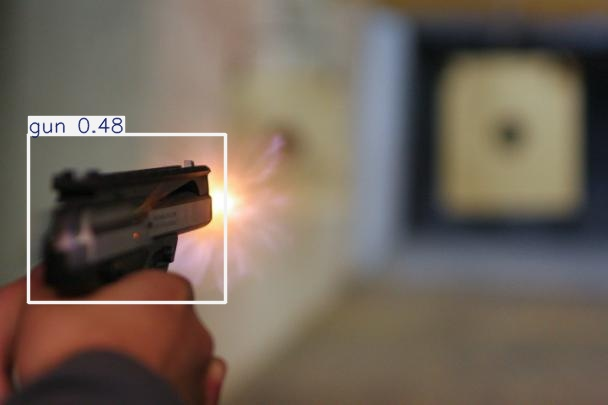

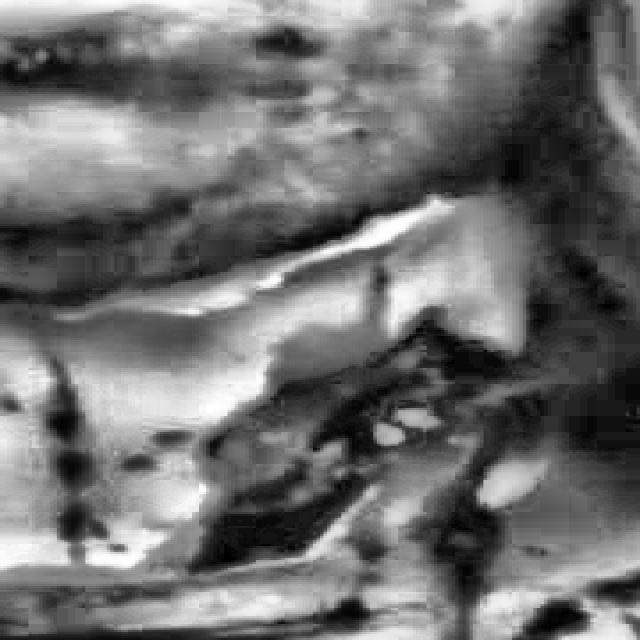

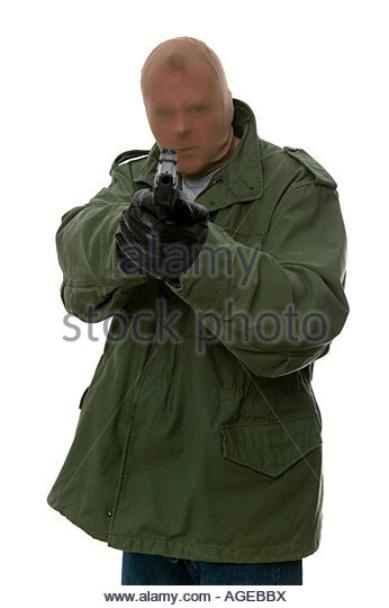

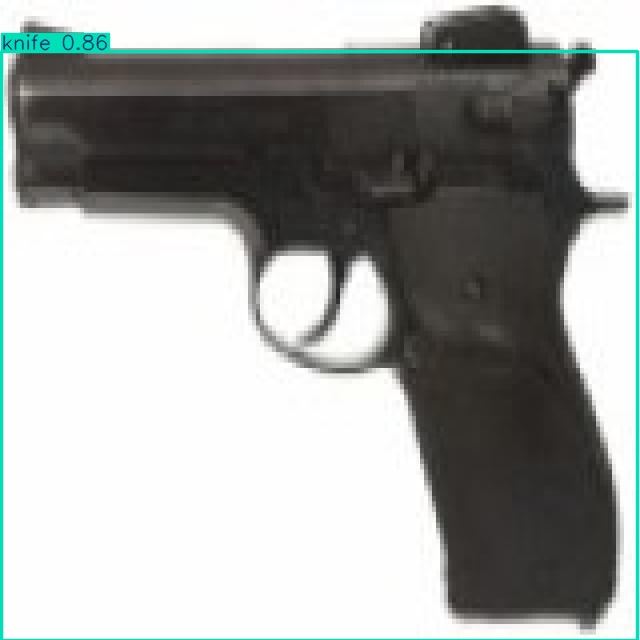

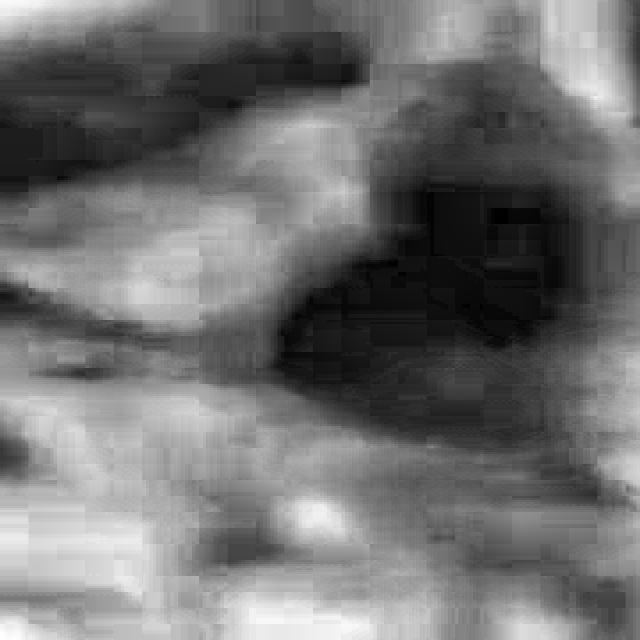

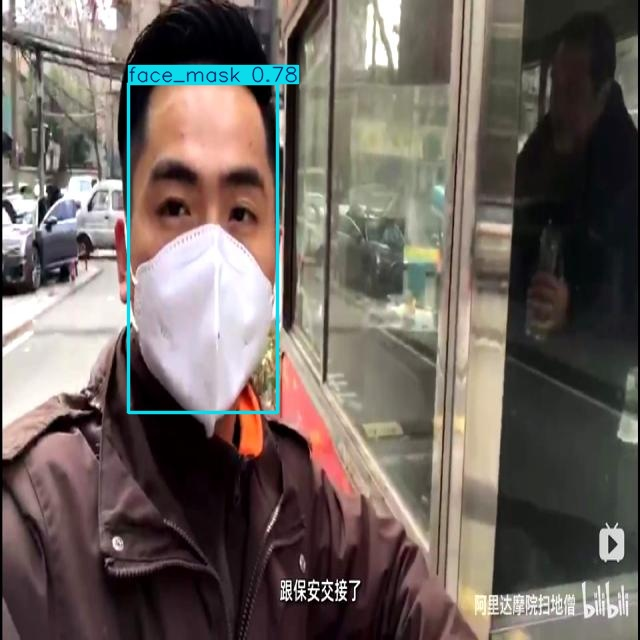

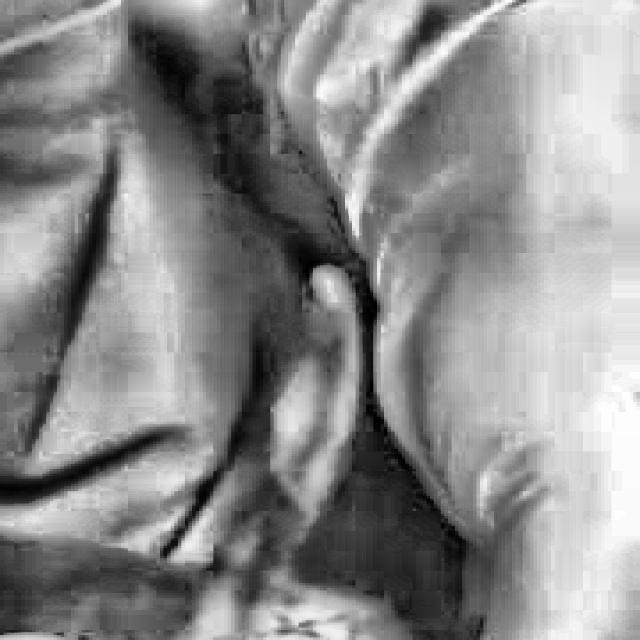

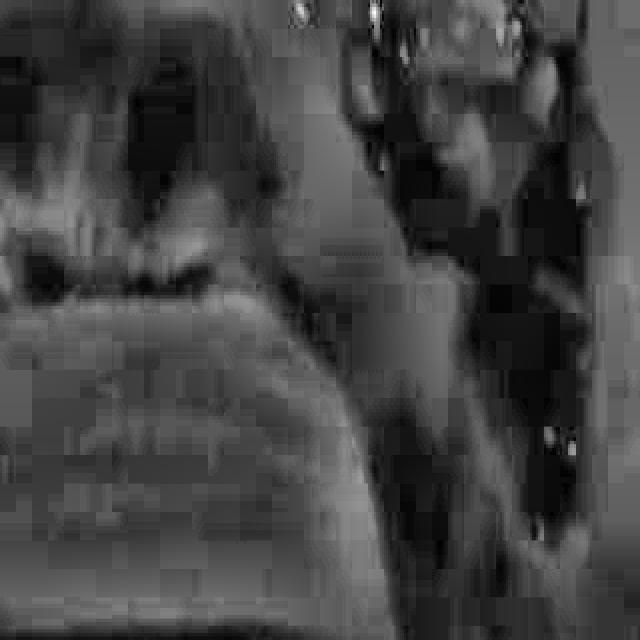

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train2/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train2 /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train2
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train2/ (stored 0%)
  adding: train2/results.png (deflated 7%)
  adding: train2/args.yaml (deflated 53%)
  adding: train2/train_batch0.jpg (deflated 3%)
  adding: train2/train_batch1.jpg (deflated 4%)
  adding: train2/train_batch5400.jpg (deflated 7%)
  adding: train2/val_batch0_pred.jpg (deflated 17%)
  adding: train2/weights/ (stored 0%)
  adding: train2/weights/last.pt (deflated 8%)
  adding: train2/weights/best.pt (deflated 8%)
  adding: train2/val_batch2_labels.jpg (deflated 8%)
  adding: train2/train_batch5401.jpg (deflated 9%)
  adding: train2/val_batch0_labels.jpg (deflated 18%)
  adding: train2/train_batch5402.jpg (deflated 11%)
  adding: train2/BoxP_curve.png (deflated 9%)
  adding: train2/BoxF1_curve.png (deflated 9%)
  adding: train2/results.csv (deflated 59%)
  adding: train2/train_batch2.jpg (deflated 3%)
  adding: train2/labels_correlogram.jpg (deflated 40%)
  adding: train2/confusion_matrix.png (deflated 28

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>